#### SECTION 2.1: IMPORT LIBRARIES

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

#### SECTION 2.2: LOAD CLEANED DATA

In [59]:
processed_path = r"D:\DevProjects\Python\AL2002-PROJECT\data\processed"

# Load events (sampled, cleaned)
events = pd.read_csv(os.path.join(processed_path, 'events_clean.csv'))
events['datetime'] = pd.to_datetime(events['datetime'])  # already saved as string, convert back

# Load category tree (will be used later for A*)
cat_tree = pd.read_csv(os.path.join(processed_path, 'category_tree_clean.csv'))

print("Events shape:", events.shape)
print("Category tree shape:", cat_tree.shape)
print(events.head())

Events shape: (500000, 6)
Category tree shape: (1669, 2)
       timestamp  visitorid event  itemid  transactionid  \
0  1435193216976      50734  view    4442            NaN   
1  1440996903983     355903  view  269631            NaN   
2  1431280237515    1066758  view  221329            NaN   
3  1439507864399    1049477  view   23683            NaN   
4  1437601159324     143239  view    6552            NaN   

                 datetime  
0 2015-06-25 00:46:56.976  
1 2015-08-31 04:55:03.983  
2 2015-05-10 17:50:37.515  
3 2015-08-13 23:17:44.399  
4 2015-07-22 21:39:19.324  


#### SECTION 2.3: FEATURE ENGINERRING FOR USER SEGMENTATION

In [60]:
# Group by visitorid
user_features = events.groupby('visitorid').agg(
    total_views=('event', lambda x: (x == 'view').sum()),
    total_addtocart=('event', lambda x: (x == 'addtocart').sum()),
    total_transactions=('event', lambda x: (x == 'transaction').sum()),
    last_activity=('datetime', 'max'),
    first_activity=('datetime', 'min')
).reset_index()

# Add ratios (avoid division by zero)
user_features['cart_to_view_ratio'] = user_features['total_addtocart'] / (user_features['total_views'] + 1e-6)
user_features['transaction_to_view_ratio'] = user_features['total_transactions'] / (user_features['total_views'] + 1e-6)

# Add unique items viewed (diversity)
unique_items = events.groupby('visitorid')['itemid'].nunique().reset_index(name='unique_items_viewed')
user_features = user_features.merge(unique_items, on='visitorid')

# Add recency (days since last activity)
user_features['recency_days'] = (events['datetime'].max() - user_features['last_activity']).dt.days

# Add approximate session count (30-minute gap)
events_sorted = events.sort_values(['visitorid', 'datetime'])
events_sorted['time_diff'] = events_sorted.groupby('visitorid')['datetime'].diff().dt.total_seconds() / 60
events_sorted['new_session'] = (events_sorted['time_diff'] > 30) | (events_sorted['time_diff'].isna())
session_counts = events_sorted.groupby('visitorid')['new_session'].sum().reset_index(name='num_sessions')
user_features = user_features.merge(session_counts, on='visitorid', how='left')
user_features['num_sessions'] = user_features['num_sessions'].fillna(1).astype(int)
user_features['avg_items_per_session'] = user_features['total_views'] / user_features['num_sessions']

print("User features shape (full, before filtering):", user_features.shape)

# Filter users with at least 2 views
user_features = user_features[user_features['total_views'] >= 2]

# Remove unrealistic ratios
user_features = user_features[user_features['cart_to_view_ratio'] <= 1]
user_features = user_features[user_features['transaction_to_view_ratio'] <= 1]

print("User features shape (after outlier removal):", user_features.shape)

# Sample 30,000 users for clustering (larger sample for better representation)
user_features_sample = user_features.sample(n=30000, random_state=42)
print("User features shape (sample for clustering):", user_features_sample.shape)

User features shape (full, before filtering): (369575, 12)
User features shape (after outlier removal): (52910, 12)
User features shape (sample for clustering): (30000, 12)


#### SECTION 2.4: SELECT FEATURES FOR CLUSTERING

In [61]:
feature_cols = ['total_views', 'total_addtocart', 'total_transactions', 
                'cart_to_view_ratio', 'transaction_to_view_ratio', 
                'unique_items_viewed', 'recency_days', 'avg_items_per_session']

X = user_features_sample[feature_cols].copy()

# Apply log1p transformation to skewed features
skewed_cols = ['total_views', 'total_addtocart', 'total_transactions', 
               'unique_items_viewed', 'avg_items_per_session']
X[skewed_cols] = np.log1p(X[skewed_cols])

X['cart_to_view_ratio'] = np.log1p(X['cart_to_view_ratio'])
X['transaction_to_view_ratio'] = np.log1p(X['transaction_to_view_ratio'])
X['recency_days'] = np.log1p(X['recency_days'])

print("Feature matrix shape (sample, transformed):", X.shape)
print(X.describe())

Feature matrix shape (sample, transformed): (30000, 8)
        total_views  total_addtocart  total_transactions  cart_to_view_ratio  \
count  30000.000000     30000.000000        30000.000000        30000.000000   
mean       1.286995         0.044345            0.018483            0.015820   
std        0.373089         0.214197            0.145992            0.076483   
min        1.098612         0.000000            0.000000            0.000000   
25%        1.098612         0.000000            0.000000            0.000000   
50%        1.098612         0.000000            0.000000            0.000000   
75%        1.386294         0.000000            0.000000            0.000000   
max        7.047517         4.934474            4.736198            0.693147   

       transaction_to_view_ratio  unique_items_viewed  recency_days  \
count               30000.000000         30000.000000  30000.000000   
mean                    0.005691             1.139916      3.942361   
std        

#### SECTION 2.5: SCALE FEATURES

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("Mean (approx 0):", X_scaled.mean(axis=0).round(2))
print("Std (approx 1):", X_scaled.std(axis=0).round(2))

Scaled data shape: (30000, 8)
Mean (approx 0): [ 0.  0. -0.  0. -0. -0.  0.  0.]
Std (approx 1): [1. 1. 1. 1. 1. 1. 1. 1.]


#### SECTION 2.6: DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD + SILHOUETTE)

k=2, silhouette=0.6874
k=3, silhouette=0.6483
k=4, silhouette=0.4109
k=5, silhouette=0.3586
k=6, silhouette=0.3563
k=7, silhouette=0.3472
k=8, silhouette=0.3547
k=9, silhouette=0.3803
k=10, silhouette=0.3813


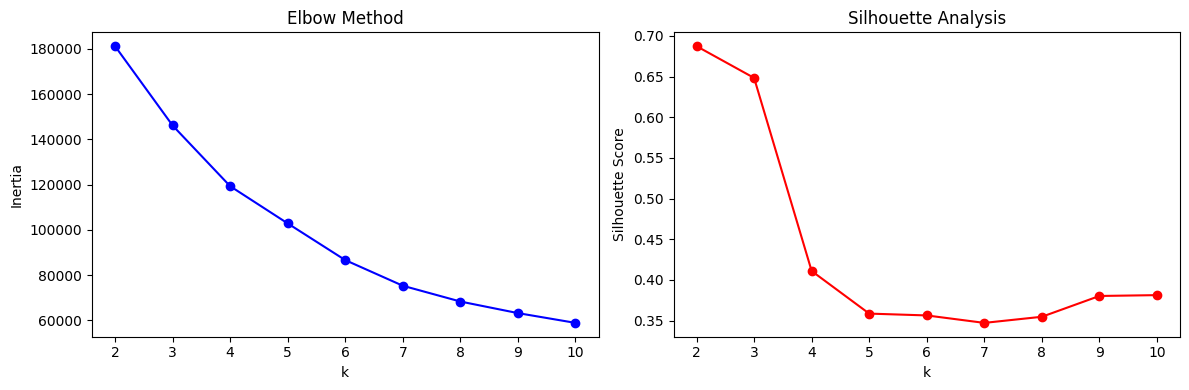

In [63]:
# (Optional) run elbow/silhouette to see scores, but we'll set k=4 manually
inertias = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil)
    print(f"k={k}, silhouette={sil:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

#### SECTION 2.7: APPLY K-MEANS WITH BEST K

In [64]:
final_k = 4
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
user_features_sample['cluster'] = kmeans.fit_predict(X_scaled)

print("Initial cluster distribution:")
print(user_features_sample['cluster'].value_counts().sort_index())

# --- Merge very small clusters (< 1% of sample) into the nearest larger cluster ---
min_cluster_size = 0.01 * len(user_features_sample)  # 1% threshold
cluster_sizes = user_features_sample['cluster'].value_counts()
small_clusters = cluster_sizes[cluster_sizes < min_cluster_size].index.tolist()

if small_clusters:
    print(f"Small clusters to merge: {small_clusters}")
    # Get cluster centers
    centers = kmeans.cluster_centers_
    for small_c in small_clusters:
        # Find the nearest larger cluster (by Euclidean distance between centers)
        other_clusters = [c for c in range(final_k) if c != small_c and c not in small_clusters]
        if not other_clusters:
            continue
        distances = [np.linalg.norm(centers[small_c] - centers[other]) for other in other_clusters]
        nearest = other_clusters[np.argmin(distances)]
        # Merge small cluster into nearest
        user_features_sample.loc[user_features_sample['cluster'] == small_c, 'cluster'] = nearest
        print(f"Merged cluster {small_c} into cluster {nearest}")
    
    # Re-number clusters to be contiguous (0,1,2,...)
    unique_clusters = sorted(user_features_sample['cluster'].unique())
    mapping = {old: new for new, old in enumerate(unique_clusters)}
    user_features_sample['cluster'] = user_features_sample['cluster'].map(mapping)
    final_k = len(unique_clusters)
    print(f"After merging, final k = {final_k}")

print("\nFinal cluster distribution:")
print(user_features_sample['cluster'].value_counts().sort_index())

Initial cluster distribution:
cluster
0     5196
1    23051
2      602
3     1151
Name: count, dtype: int64

Final cluster distribution:
cluster
0     5196
1    23051
2      602
3     1151
Name: count, dtype: int64


#### SECTION 2.8: VISUALIZE CLUSTERS USING PCA

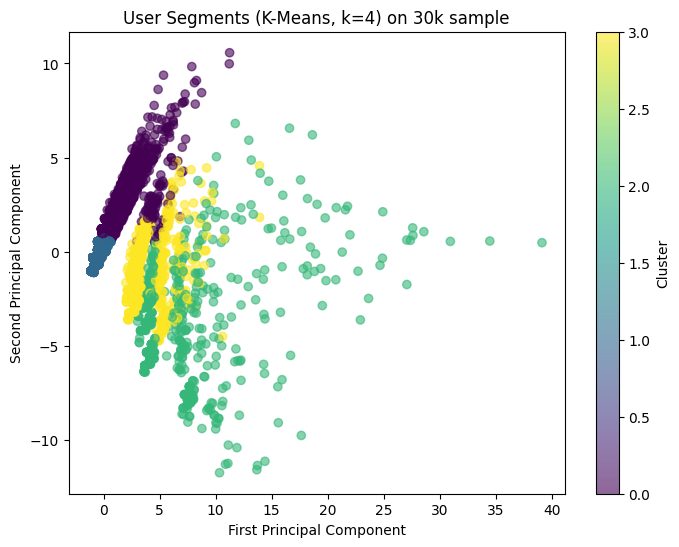

PCA explained variance ratio: [0.3596969 0.1914624]


In [65]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=user_features_sample['cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'User Segments (K-Means, k={final_k}) on 30k sample')
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

#### SECTION 2.9: INTERPRET CLUSTERS (MEAN FEATURE VALUES PER CLUSTER)

In [66]:
cluster_summary = user_features_sample.groupby('cluster')[feature_cols].mean()
print(cluster_summary.round(2))

         total_views  total_addtocart  total_transactions  cart_to_view_ratio  \
cluster                                                                         
0               5.80             0.02                 0.0                0.00   
1               2.22             0.00                 0.0                0.00   
2              16.97             2.03                 2.2                0.15   
3               3.93             1.35                 0.0                0.42   

         transaction_to_view_ratio  unique_items_viewed  recency_days  \
cluster                                                                 
0                             0.00                 4.71         68.73   
1                             0.00                 1.79         67.18   
2                             0.34                17.19         64.41   
3                             0.00                 3.94         65.66   

         avg_items_per_session  
cluster                         
0       

#### Section 2.10: Build Item-Item KNN Recommender

In [67]:
from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

# Get top popular items (reduce to 2000 to save memory)
item_popularity = events['itemid'].value_counts()
top_items = item_popularity.head(2000).index  # reduced from 5000 to 2000

# Filter events to only top items
events_top = events[events['itemid'].isin(top_items)]

# Create mappings: user -> row index, item -> col index
users = events_top['visitorid'].unique()
items = top_items

user_to_idx = {uid: i for i, uid in enumerate(users)}
item_to_idx = {iid: j for j, iid in enumerate(items)}

# Build sparse matrix (rows=users, cols=items, value=1 if interaction)
rows = []
cols = []
for uid, iid in zip(events_top['visitorid'], events_top['itemid']):
    rows.append(user_to_idx[uid])
    cols.append(item_to_idx[iid])

# Create sparse matrix (boolean interactions)
data = [1] * len(rows)
user_item_sparse = csr_matrix((data, (rows, cols)), shape=(len(users), len(items)))

print("User-item sparse matrix shape:", user_item_sparse.shape)
print("Non-zero entries:", user_item_sparse.nnz)
print("Memory usage: ~", user_item_sparse.data.nbytes / 1e6, "MB")

User-item sparse matrix shape: (83720, 2000)
Non-zero entries: 95708
Memory usage: ~ 0.765664 MB


#### Section 2.11: Fit KNN Model on Item-Item Similarity

In [68]:
# Transpose: items as rows, users as columns
item_user_sparse = user_item_sparse.T  # shape: (n_items, n_users)

# Fit NearestNeighbors on sparse item vectors
# Use 'brute' with metric='cosine' works with sparse
knn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn.fit(item_user_sparse)

print("KNN model fitted on", item_user_sparse.shape[0], "items")

KNN model fitted on 2000 items


#### Section 2.12: Function to Get Similar Items

In [69]:
def get_similar_items(item_id, n_recommendations=5):
    """
    Given an item_id, return top n similar items using KNN on sparse matrix.
    """
    if item_id not in item_to_idx:
        return f"Item {item_id} not in top {len(top_items)} items list."
    
    idx = item_to_idx[item_id]
    distances, indices = knn.kneighbors(item_user_sparse[idx].reshape(1, -1))
    
    # indices[0][0] is the item itself (distance 0), so start from 1
    similar_item_indices = indices[0][1: n_recommendations+1]
    similar_items = [list(items)[i] for i in similar_item_indices]
    return similar_items

# Test example
test_item = top_items[0]
print(f"Item {test_item} is similar to:")
print(get_similar_items(test_item, 5))

Item 187946 is similar to:
[126126, 89247, 289633, 448044, 92361]


#### Section 2.13: Save Clusters and KNN Model for Later Use

In [70]:
import pickle

# Save user cluster assignments (full user_features_sample we already have)
user_features_sample[['visitorid', 'cluster']].to_csv(os.path.join(processed_path, 'user_clusters_sample.csv'), index=False)

# Save kmeans and scaler (as before)
with open(os.path.join(processed_path, 'kmeans_model.pkl'), 'wb') as f:
    pickle.dump(kmeans, f)
with open(os.path.join(processed_path, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save sparse matrix and mappings for KNN
save_npz(os.path.join(processed_path, 'item_user_sparse.npz'), item_user_sparse)
with open(os.path.join(processed_path, 'item_to_idx.pkl'), 'wb') as f:
    pickle.dump(item_to_idx, f)
with open(os.path.join(processed_path, 'top_items_list.pkl'), 'wb') as f:
    pickle.dump(top_items, f)

# Save the knn model (optional, can re-fit later)
with open(os.path.join(processed_path, 'knn_model.pkl'), 'wb') as f:
    pickle.dump(knn, f)

print("All artifacts saved (sparse).")

All artifacts saved (sparse).


#### Section 2.14: Quick Verification

In [71]:
# Test loading
test_user_clusters = pd.read_csv(os.path.join(processed_path, 'user_clusters_sample.csv'))
print("Clusters sample shape:", test_user_clusters.shape)

# Test loading sparse matrix
test_sparse = load_npz(os.path.join(processed_path, 'item_user_sparse.npz'))
print("Loaded sparse matrix shape:", test_sparse.shape)

Clusters sample shape: (30000, 2)
Loaded sparse matrix shape: (2000, 83720)
